/var/folders/yp/078pyxw11mq6g7sd_2ty18z80000gn/T/ipykernel_23701/3155098115.py:5: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit import QuantumCircuit



QUANTUM RANDOMNESS EXPERIMENT

Quantum Circuit:
        ┌───┐ ░ ┌─┐
     q: ┤ H ├─░─┤M├
        └───┘ ░ └╥┘
meas: 1/═════════╩═
                 0 

QUANTUM RESULTS
Shots       : 10000
0 count     : 5066
1 count     : 4934
P(1)        : 0.4934
Z-score     : -1.3200

CLASSICAL BIASED RESULTS
Shots       : 10000
0 count     : 3507
1 count     : 6493
P(1)        : 0.6493
Z-score     : 29.8600

HYPOTHESIS TEST
H0: P(1) = 0.5
H1: P(1) != 0.5
Significance level = 0.05
Critical z-value = ±1.96

Quantum Generator:
FAIL TO REJECT H0
Data is consistent with a fair 50/50 source.

Classical Generator:
REJECT H0
Strong evidence of bias.

FINAL COMPARISON
Quantum P(1)   = 0.4934
Classical P(1) = 0.6493

Quantum Z-score   = -1.3200
Classical Z-score = 29.8600


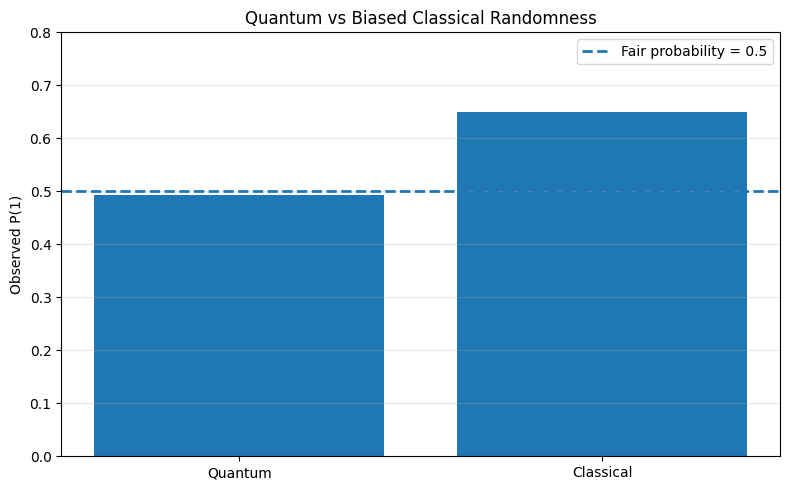

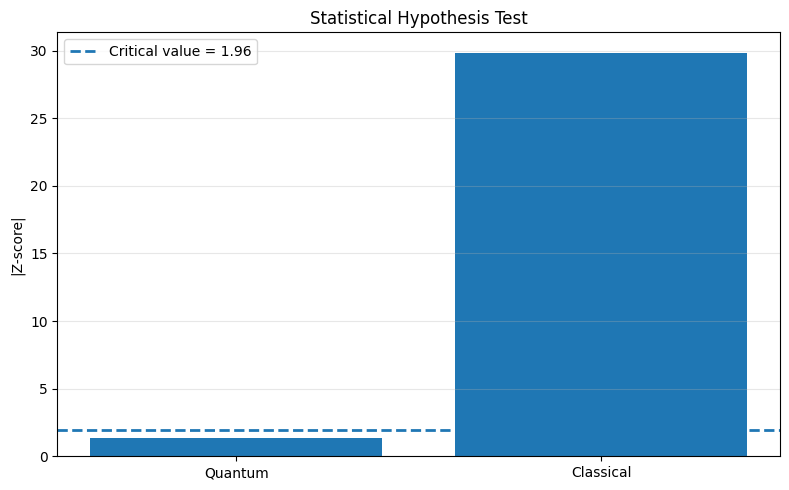

In [1]:
import math
import random
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler

shots = 10000

sampler = StatevectorSampler()

quantum_circuit = QuantumCircuit(1)

quantum_circuit.h(0)

quantum_circuit.measure_all()

print("\nQUANTUM RANDOMNESS EXPERIMENT")
print("=" * 65)

print("\nQuantum Circuit:")
print(quantum_circuit.draw())

quantum_result = sampler.run(
    [quantum_circuit],
    shots=shots
).result()

quantum_counts = quantum_result[0].data.meas.get_counts()

quantum_zeros = quantum_counts.get("0", 0)
quantum_ones = quantum_counts.get("1", 0)

quantum_p1 = quantum_ones / shots

classical_probability = 0.65

classical_ones = sum(
    1
    for _ in range(shots)
    if random.random() < classical_probability
)

classical_zeros = shots - classical_ones

classical_p1 = classical_ones / shots


def calculate_z(observed_probability, expected_probability, n):

    standard_error = math.sqrt(
        expected_probability
        * (1 - expected_probability)
        / n
    )

    z = (
        observed_probability
        - expected_probability
    ) / standard_error

    return z


quantum_z = calculate_z(
    quantum_p1,
    0.5,
    shots
)

classical_z = calculate_z(
    classical_p1,
    0.5,
    shots
)

critical_value = 1.96

print("\nQUANTUM RESULTS")
print("=" * 65)

print(f"Shots       : {shots}")
print(f"0 count     : {quantum_zeros}")
print(f"1 count     : {quantum_ones}")
print(f"P(1)        : {quantum_p1:.4f}")
print(f"Z-score     : {quantum_z:.4f}")

print("\nCLASSICAL BIASED RESULTS")
print("=" * 65)

print(f"Shots       : {shots}")
print(f"0 count     : {classical_zeros}")
print(f"1 count     : {classical_ones}")
print(f"P(1)        : {classical_p1:.4f}")
print(f"Z-score     : {classical_z:.4f}")

print("\nHYPOTHESIS TEST")
print("=" * 65)

print("H0: P(1) = 0.5")
print("H1: P(1) != 0.5")
print("Significance level = 0.05")
print("Critical z-value = ±1.96")

print("\nQuantum Generator:")

if abs(quantum_z) > critical_value:
    print("REJECT H0")
    print("Evidence of statistically significant bias.")
else:
    print("FAIL TO REJECT H0")
    print("Data is consistent with a fair 50/50 source.")

print("\nClassical Generator:")

if abs(classical_z) > critical_value:
    print("REJECT H0")
    print("Strong evidence of bias.")
else:
    print("FAIL TO REJECT H0")
    print("No statistically significant bias detected.")

print("\nFINAL COMPARISON")
print("=" * 65)

print(
    f"Quantum P(1)   = {quantum_p1:.4f}"
)

print(
    f"Classical P(1) = {classical_p1:.4f}"
)

print(
    f"\nQuantum Z-score   = {quantum_z:.4f}"
)

print(
    f"Classical Z-score = {classical_z:.4f}"
)

labels = [
    "Quantum",
    "Classical"
]

probabilities = [
    quantum_p1,
    classical_p1
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    labels,
    probabilities
)

plt.axhline(
    0.5,
    linestyle="--",
    linewidth=2,
    label="Fair probability = 0.5"
)

plt.ylabel("Observed P(1)")

plt.title("Quantum vs Biased Classical Randomness")

plt.ylim(0, 0.8)

plt.grid(axis="y", alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()


sources = [
    "Quantum",
    "Classical"
]

z_scores = [
    abs(quantum_z),
    abs(classical_z)
]

plt.figure(figsize=(8, 5))

plt.bar(
    sources,
    z_scores
)

plt.axhline(
    critical_value,
    linestyle="--",
    linewidth=2,
    label="Critical value = 1.96"
)

plt.ylabel("|Z-score|")

plt.title("Statistical Hypothesis Test")

plt.grid(axis="y", alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()